# Week 6 Lab — Structure in Random Graphs

This lab goes further on the models for random graphs that uncover and impose additional structure like that found in real-world graphs. In this lab we particularly focus on those models touched on during the lectures:
1. Configuration model
    - Adjacency representation
    - Graph representation
    - Correspondece to Erdős–Rényi
    - Large networks
    
    
2. Directed configuration
3. Bipartite configuration
4. Tree generation
5. Stochastic block model
6. Small worlds (Watts-Strogatz)

In [89]:
import igraph as ig
import numpy as np
import scipy as sp
import matplotlib.pyplot as plt

## Configuration model 

IGRAPH U--- 4 4 --
+ edges:
0--1 0--2 1--2 0--3
IGRAPH U--- 4 4 --
+ edges:
0--1 0--2 0--3 1--2
Adjacency matrix (small configuration model):
[[0 1 1 1]
 [1 0 1 0]
 [1 1 0 0]
 [1 0 0 0]]


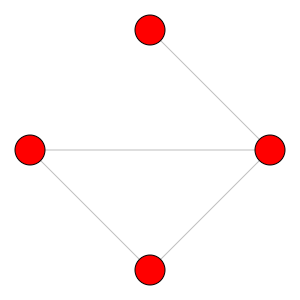

In [144]:
# (a) Adjacency representation
degrees = [3, 2, 2, 1]   # sum = 8, valid
g_conf = ig.Graph.Degree_Sequence(degrees, method="configuration")
print(g_conf)
ig.plot(
    g_conf,
    layout=g_conf.layout("circle"),
    vertex_size=30,
    edge_color="gray",
    bbox=(300,300),
    margin=30
)
g_conf = g_conf.simplify(multiple=True, loops=True)
print(g_conf)

A = np.array(g_conf.get_adjacency().data)
print("Adjacency matrix (small configuration model):")
print(A)

# (b) Graph representation
ig.plot(
    g_conf,
    layout=g_conf.layout("circle"),
    vertex_size=30,
    edge_color="gray",
    bbox=(300,300),
    margin=30
)

### Correspondence to ER graphs

Degree sequence (Poisson distribution): [ 2  6  5  5  3  7  5  2  5  7  3  6  4  6  2  2  5  9  7  3  3  5  6  1
  3  6 11  6  5  6  5  2  6  3  3  5  9  3  9  2  7  5  5  4  4  5  3  9
  4  3  3  3  1  6  0  3  6  6  8  6  8  2  8  6  6  2  4  8  5  6  6  7
  6  6  3  2  4  7  4  3  6  5  6  2  7  5  5 10  3 10  7  3  7  4 13  7
  3  4  8  3  7]


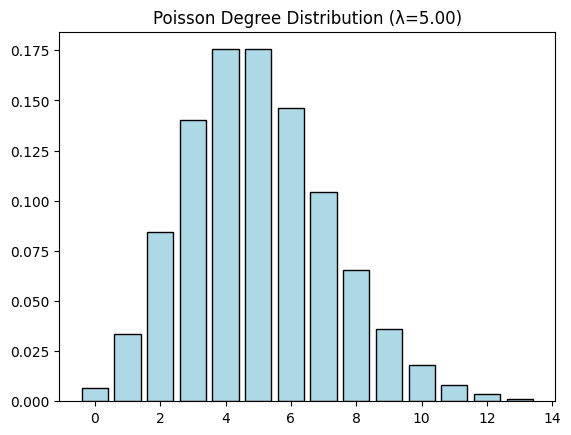

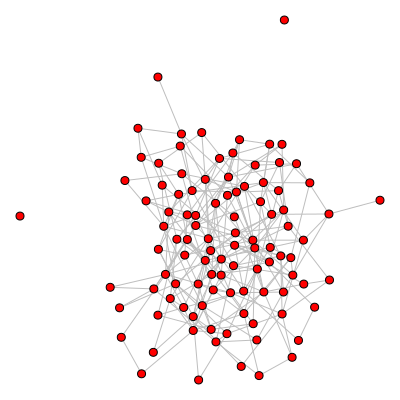

In [147]:
# Poisson degree distribution
n = 101
p = 0.05
lambda_deg = (n - 1) * p

degrees = np.random.poisson(lambda_deg, n)
if degrees.sum() % 2 != 0:
    degrees[0] += 1
print("Degree sequence (Poisson distribution):", degrees)

# Draw Poisson density with given lambda
x = np.arange(0, max(degrees)+1)
poisson_pmf = (lambda_deg**x * np.exp(-lambda_deg)) / sp.special.factorial(x)
plt.bar(x, poisson_pmf, color='lightblue', edgecolor='black')
plt.title(f'Poisson Degree Distribution (λ={lambda_deg:.2f})')
plt.show()

g_conf = ig.Graph.Degree_Sequence(
    degrees.tolist(),
    method="configuration"
).simplify(multiple=True, loops=True)

ig.plot(
    g_conf,
    layout=g_conf.layout("fr"),
    vertex_size=8,
    edge_color="gray",
    bbox=(400,400),
    margin=20
)

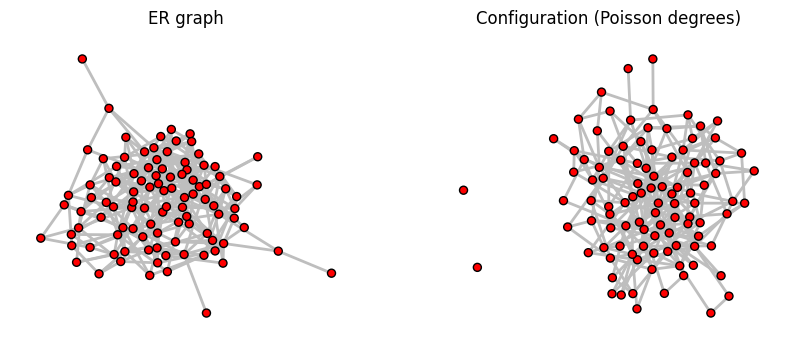

In [149]:
# Correspondence to Erdős–Rényi
g_er = ig.Graph.Erdos_Renyi(n=n, p=p)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ig.plot(
    g_er,
    target=axes[0],
    layout=g_er.layout("fr"),
    vertex_size=8,
    edge_color="gray"
)
axes[0].set_title("ER graph")

ig.plot(
    g_conf,
    target=axes[1],
    layout=g_conf.layout("fr"),
    vertex_size=8,
    edge_color="gray"
)
axes[1].set_title("Configuration (Poisson degrees)")

plt.show()

[1 0 0 0 0 0 0 0 0 0 0 0 1 0 0 0 0 1 1 0 0 1 2 1 0 1 0 0 0 0 1 0 0 1 0 0 0
 0 0 0 1 0 0 0 1 0 1 0 0 0]


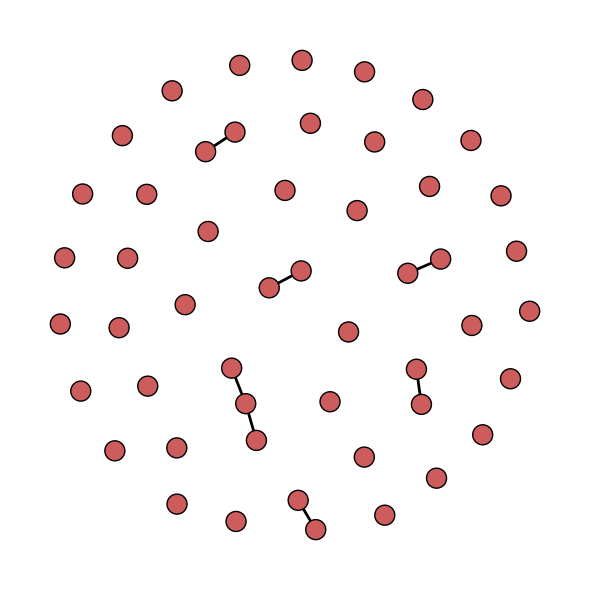

[1 0 0 1 0 1 1 1 0 0 0 0 2 0 1 1 1 0 0 0 1 0 0 2 2 2 0 0 2 0 0 1 0 0 1 1 1
 0 0 0 1 0 1 1 0 0 1 1 0 0]


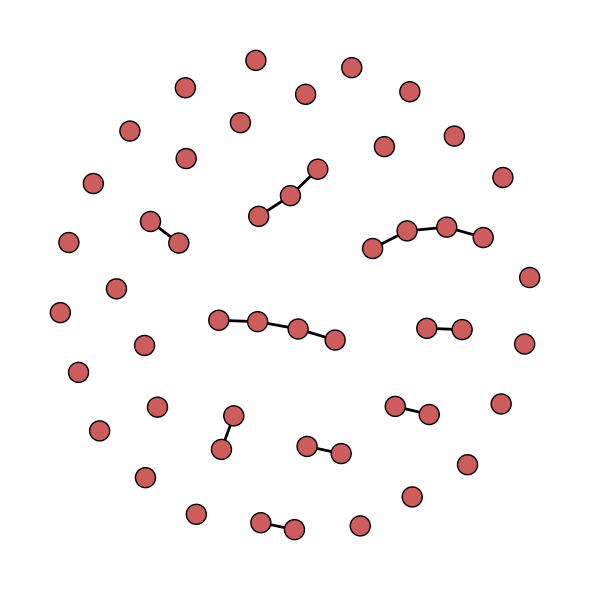

[1 1 0 0 0 1 1 0 0 0 0 1 1 1 0 0 0 1 0 0 0 1 2 1 0 1 2 0 0 1 1 1 0 3 0 1 0
 0 0 0 1 0 0 0 0 1 0 1 0 1]


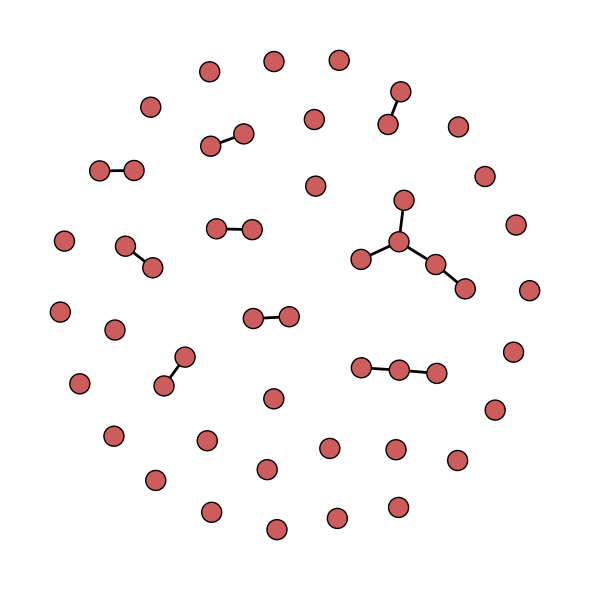

[3 3 0 2 2 1 1 1 1 1 0 0 0 2 1 4 1 2 4 2 1 2 1 3 2 1 0 0 2 2 1 0 1 0 2 1 2
 1 0 2 1 3 1 1 3 2 1 0 4 1]


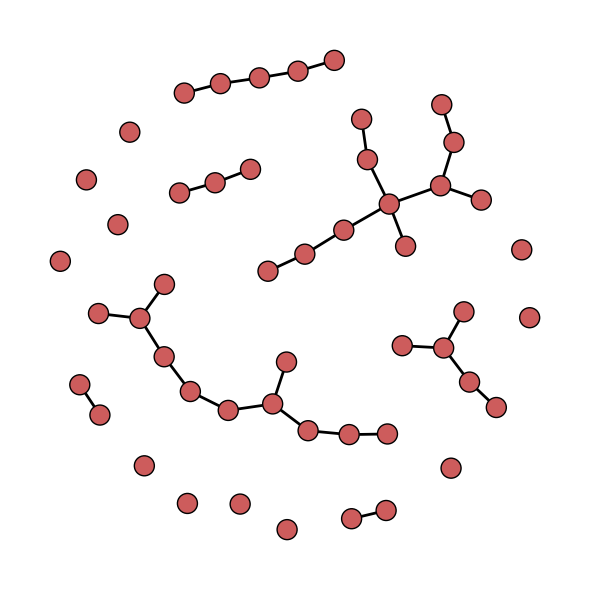

[2 4 2 2 3 1 3 2 2 2 6 3 2 3 0 0 0 4 2 1 5 5 1 5 5 2 2 3 0 2 1 0 1 4 1 2 2
 4 1 4 1 3 1 4 5 1 8 1 2 2]


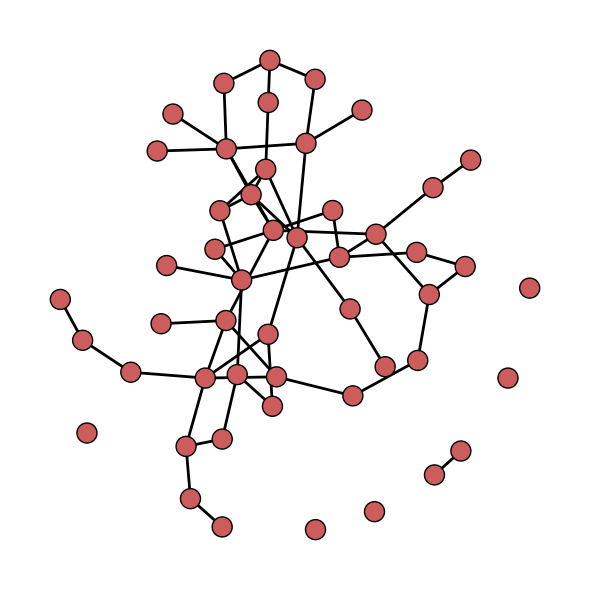

[5 5 7 3 3 6 5 3 7 5 1 4 2 2 3 7 2 2 7 8 1 3 2 1 5 2 4 6 3 3 3 5 5 4 6 4 4
 5 6 6 4 4 4 3 1 2 7 4 5 3]


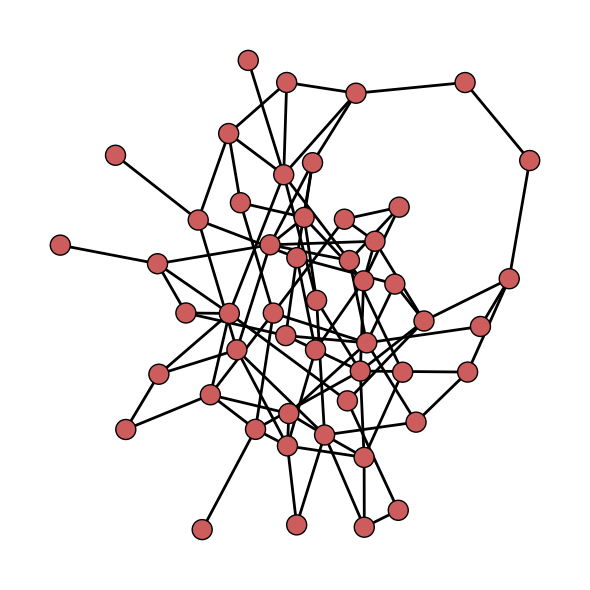

[ 4  9  2  6  3  5  6  3  5  9  7  8  3  8  8 10 11  4  3  3  9  7  6  3
  6  8  8  8  8  8  2  8  6  6 12  5  5  0  9  8  5  4  2  4  7  8  9  7
 10  3]


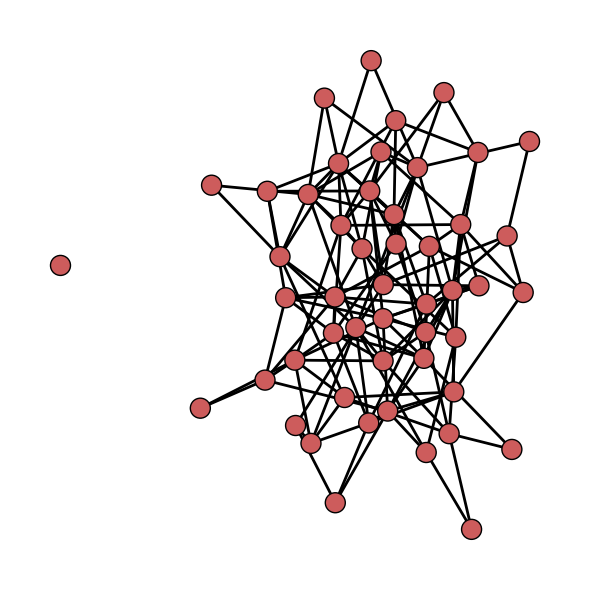

[16  9 11  6 14 12 11 13 14 17 10  9 16 13  7 18 12 13 14 10 14  7  8 14
 18 14 17 17 15 13 14 14 15 11 10 17 13  9  9  9 13 12 11 13  8 11 16 10
 10  9]


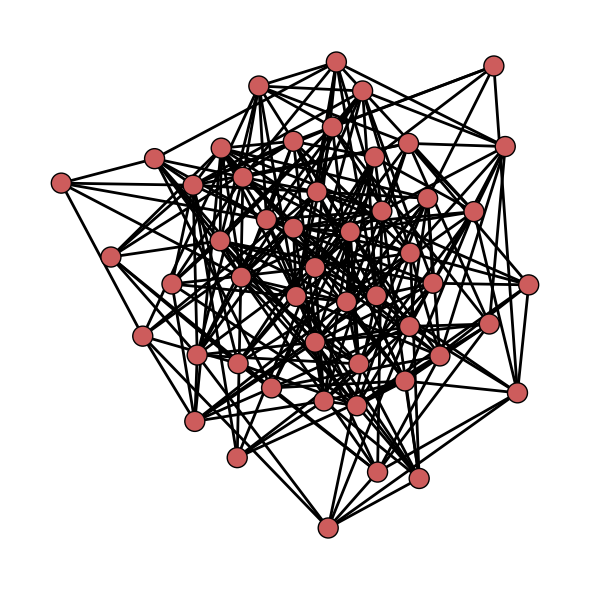

In [150]:
# Simulate phase transitions by plotting behaviour from configuration model similar to ER from large n with given p values
n = 50
N = n * (n - 1) / 2  # Total possible edges in an undirected graph without self-loops
p_values = np.array([.0002, .0003, .0005, .001, .002, .003, .005, .01])
rng = np.random.default_rng(seed=123456789)  # Set seed for reproducibility
for index, p in enumerate(p_values):
    # Draw degree sequence from a Poisson distribution with mean equal to the expected number of edges in the ER model
    lam = p * N  # Expected number of edges
    degrees = np.random.poisson(lam, n)

    # Ensure sum of degrees is even
    if degrees.sum() % 2 != 0:
        degrees[0] += 1
    
    # Sample from configuration model using the degree sequence
    print(degrees)
    g_config = ig.Graph.Degree_Sequence(
        degrees,
        method="configuration"
    )
    
    # Simplify (remove multi-edges and loops)
    g_config = g_config.simplify(multiple=True, loops=True)

    # Plot and save the graph
    fig, ax = plt.subplots(figsize=(6, 6))
    ig.plot(g_config, target=ax, vertex_size=20, vertex_color='indianred', edge_color='black', layout='fr')
    plt.tight_layout()
    plt.show()

## Directed configuration

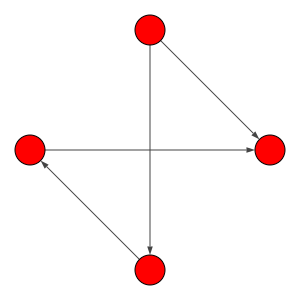

In [154]:
in_degrees  = [2,1,1,0]
out_degrees = [0,1,1,2]   # sums must match

g_dir = ig.Graph.Degree_Sequence(
    out_degrees,
    in_degrees,
    method="configuration"
).simplify(multiple=True, loops=True)

ig.plot(
    g_dir,
    layout=g_dir.layout("circle"),
    vertex_size=30,
    edge_arrow_size=0.6,
    bbox=(300,300),
    margin=30
)

## Bipartite configuration

IGRAPH U--T 6 0 --
+ attr: type (v)


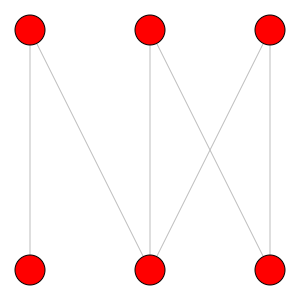

In [161]:
# Left nodes (firms), right nodes (workers)
deg_left  = [3,2,1]
deg_right = [2,2,2]
# Degree list: 000112 (Left set) and 001122 (Right set)

g_bip = ig.Graph.Bipartite(
    types=[0]*len(deg_left) + [1]*len(deg_right),
    edges=[]
)
print(g_bip)

# Manual stub matching
left_nodes  = np.repeat(range(len(deg_left)), deg_left)
right_nodes = np.repeat(range(len(deg_left), len(deg_left)+len(deg_right)), deg_right)

np.random.shuffle(right_nodes)
edges_bip = list(zip(left_nodes, right_nodes))

g_bip.add_edges(edges_bip)

ig.plot(
    g_bip.simplify(multiple=True, loops=True),
    layout=g_bip.layout_bipartite(),
    vertex_size=30,
    edge_color="gray",
    bbox=(300,300),
    margin=30
)

## Tree generation

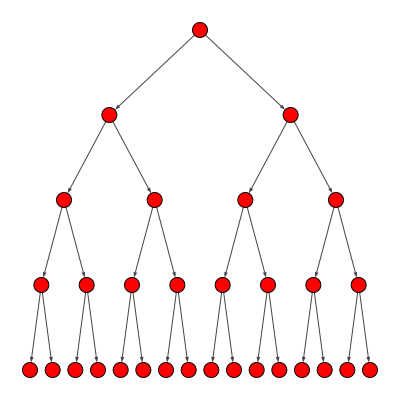

In [162]:
# Fixed branching factor tree
g_tree = ig.Graph.Tree(n=31, children=2, mode="out")

ig.plot(
    g_tree,
    layout=g_tree.layout_reingold_tilford(),
    vertex_size=15,
    edge_arrow_size=0.4,
    bbox=(400,400),
    margin=30
)

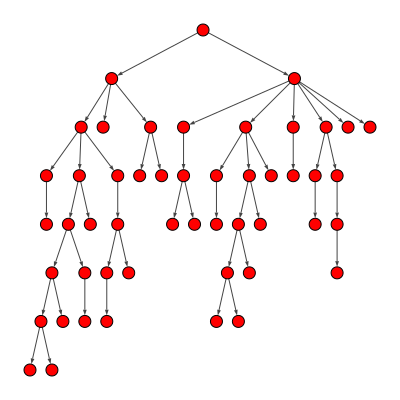

In [167]:
# Random recursive tree (each new node attaches to an existing one)
n_rrt = 50

edges_rrt = []
for i in range(1, n_rrt):
    parent = np.random.randint(0, i)
    edges_rrt.append((parent, i))

g_rrt = ig.Graph(edges=edges_rrt, directed=True)

ig.plot(
    g_rrt,
    layout=g_rrt.layout_reingold_tilford(),
    vertex_size=12,
    edge_arrow_size=0.4,
    bbox=(400,400),
    margin=30
)

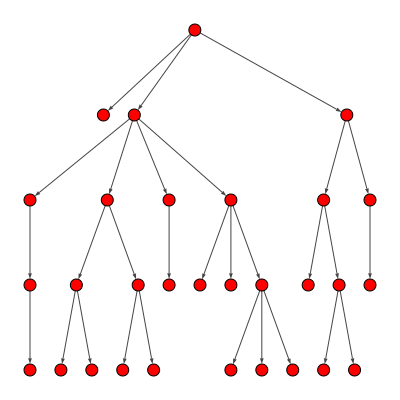

In [168]:
# Layer-constrained tree (fixed maximum depth, random parent within previous layer)
n_layers = 5
nodes_per_layer = [1, 3, 6, 10, 10]

edges_layered = []
current_node = 0
layers = [[current_node]]

for layer_size in nodes_per_layer[1:]:
    prev_layer = layers[-1]
    new_layer = []
    for _ in range(layer_size):
        current_node += 1
        parent = np.random.choice(prev_layer)
        edges_layered.append((parent, current_node))
        new_layer.append(current_node)
    layers.append(new_layer)

g_layered = ig.Graph(edges=edges_layered, directed=True)

ig.plot(
    g_layered,
    layout=g_layered.layout_reingold_tilford(),
    vertex_size=12,
    edge_arrow_size=0.4,
    bbox=(400,400),
    margin=30
)

## Stochastic block model (SBM)

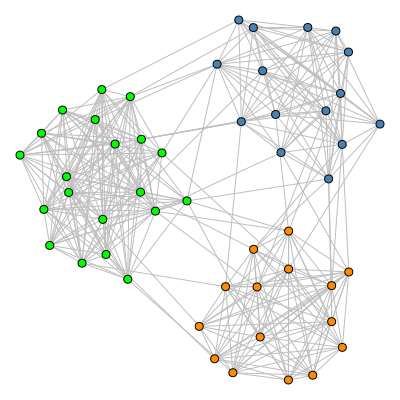

In [171]:
# Stochastic block model example
sizes = [15, 15, 20] # Community sizes (K = 3 communities)
p_within = 0.8
p_between = 0.05

pref_matrix = [
    [p_within,  p_between, p_between],
    [p_between, p_within,  p_between],
    [p_between, p_between, p_within ]
]

# Membership vector: assigns each node to a block
membership = (
    [0]*sizes[0] +
    [1]*sizes[1] +
    [2]*sizes[2]
)

g_sbm = ig.Graph.SBM(
    block_sizes=sizes,
    pref_matrix=pref_matrix
)

ig.plot(
    g_sbm,
    layout=g_sbm.layout("kamada_kawai"),
    vertex_size=8,
    vertex_color=[
        "steelblue" if m == 0 else
        "darkorange" if m == 1 else
        "green"
        for m in membership
    ],
    edge_color="gray",
    bbox=(400,400),
    margin=20
)

[[0 1 0 ... 0 0 0]
 [1 0 1 ... 0 0 0]
 [0 1 0 ... 0 0 0]
 ...
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 0 0 1]
 [0 0 0 ... 1 1 0]]


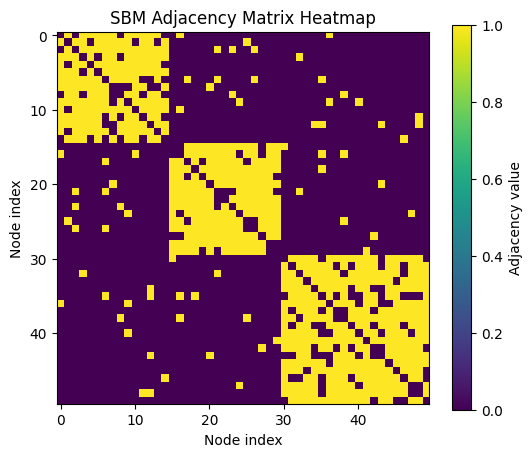

In [172]:
# Stochastic block model adjacency
A = np.array(g_sbm.get_adjacency())
print(A)

plt.figure(figsize=(6, 5))
plt.imshow(A, cmap="viridis", interpolation="nearest")
plt.colorbar(label="Adjacency value")
plt.title("SBM Adjacency Matrix Heatmap")
plt.xlabel("Node index")
plt.ylabel("Node index")
plt.show()

## Small world network (Watts-Strogatz model)

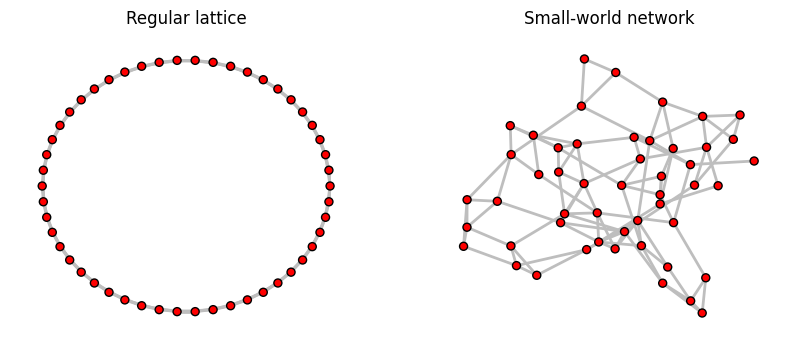

In [182]:
n_sw = 50
k_sw = 4
fraction_rewired = 0.1

g_lattice = ig.Graph.Watts_Strogatz(1, n_sw, k_sw//2, 0)
g_world = ig.Graph.Watts_Strogatz(1, n_sw, k_sw//2, fraction_rewired)

fig, axes = plt.subplots(1, 2, figsize=(10,4))

ig.plot(
    g_lattice,
    target=axes[0],
    layout=g_lattice.layout("circle"),
    vertex_size=8,
    edge_color="gray"
)
axes[0].set_title("Regular lattice")

ig.plot(
    g_world,
    target=axes[1],
    layout=g_world.layout("fr"),
    vertex_size=8,
    edge_color="gray"
)
axes[1].set_title("Small-world network")

plt.show()